In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/clean_stock_data.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"])

df["Daily_Return"] = df.groupby("Ticker")["Close"].pct_change()
df = df.dropna()

In [3]:
returns = df.pivot(index="Date", columns="Ticker", values="Daily_Return")
returns = returns.dropna()

returns.head()

Ticker,BND,SPY,TSLA
Date,,,
2015-01-06,0.002895,-0.009419,0.005664
2015-01-07,0.000602,0.012461,-0.001562
2015-01-08,-0.001563,0.017745,-0.001564
2015-01-09,0.001686,-0.008014,-0.018802
2015-01-12,0.001322,-0.007834,-0.021533


In [4]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

print("Mean Returns:")
print(mean_returns)

print("\nCovariance Matrix:")
print(cov_matrix)

Mean Returns:
Ticker
BND    -0.000035
SPY     0.000513
TSLA    0.001818
dtype: float64

Covariance Matrix:
Ticker       BND       SPY      TSLA
Ticker                              
BND     0.000011  0.000004  0.000007
SPY     0.000004  0.000125  0.000197
TSLA    0.000007  0.000197  0.001297


In [5]:
trading_days = 252

annual_returns = mean_returns * trading_days
annual_cov = cov_matrix * trading_days

In [6]:
num_portfolios = 10000
results = np.zeros((3, num_portfolios))
weights_record = []

np.random.seed(42)

for i in range(num_portfolios):

    weights = np.random.random(len(returns.columns))
    weights /= np.sum(weights)

    portfolio_return = np.dot(weights, annual_returns)
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(annual_cov, weights)))

    sharpe_ratio = portfolio_return / portfolio_risk

    results[0, i] = portfolio_return
    results[1, i] = portfolio_risk
    results[2, i] = sharpe_ratio

    weights_record.append(weights)

In [7]:
results_df = pd.DataFrame(results.T, columns=["Return", "Risk", "Sharpe"])
results_df.head()

,Return,Risk,Sharpe
0,0.221167,0.254851,0.867830
1,0.094841,0.123778,0.766215
2,0.253639,0.288525,0.879088
3,0.259462,0.329612,0.787174
4,0.084321,0.112311,0.750778


In [8]:
max_sharpe_idx = results_df["Sharpe"].idxmax()
best_portfolio = results_df.loc[max_sharpe_idx]

best_weights = weights_record[max_sharpe_idx]

print("Best Portfolio (Max Sharpe):")
print(best_portfolio)
print("\nWeights:")
for ticker, weight in zip(returns.columns, best_weights):
    print(f"{ticker}: {weight:.2%}")

Best Portfolio (Max Sharpe):
Return    0.223745
Risk      0.251533
Sharpe    0.889526
Name: 8101, dtype: float64

Weights:
BND: 0.15%
SPY: 71.08%
TSLA: 28.77%


In [9]:
min_risk_idx = results_df["Risk"].idxmin()
min_risk_portfolio = results_df.loc[min_risk_idx]

min_weights = weights_record[min_risk_idx]

print("Minimum Risk Portfolio:")
print(min_risk_portfolio)

print("\nWeights:")
for ticker, weight in zip(returns.columns, min_weights):
    print(f"{ticker}: {weight:.2%}")

Minimum Risk Portfolio:
Return   -0.002849
Risk      0.052999
Sharpe   -0.053748
Name: 8282, dtype: float64

Weights:
BND: 96.56%
SPY: 3.08%
TSLA: 0.37%


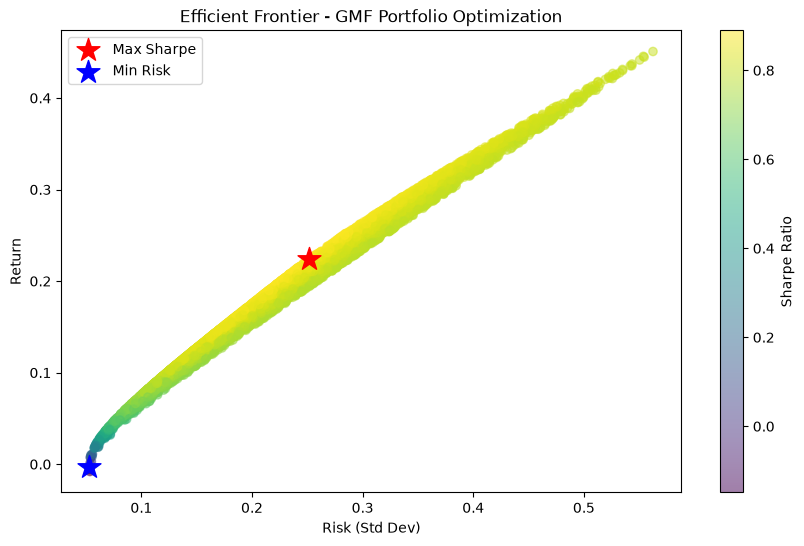

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(
    results_df["Risk"],
    results_df["Return"],
    c=results_df["Sharpe"],
    cmap="viridis",
    alpha=0.5
)

plt.colorbar(label="Sharpe Ratio")

plt.scatter(
    best_portfolio["Risk"],
    best_portfolio["Return"],
    color="red",
    marker="*",
    s=300,
    label="Max Sharpe"
)

plt.scatter(
    min_risk_portfolio["Risk"],
    min_risk_portfolio["Return"],
    color="blue",
    marker="*",
    s=300,
    label="Min Risk"
)

plt.xlabel("Risk (Std Dev)")
plt.ylabel("Return")
plt.title("Efficient Frontier - GMF Portfolio Optimization")
plt.legend()
plt.show()

In [11]:
benchmark_weights = np.array([0.4, 0.6, 0.0])  # BND, SPY, TSLA order assumed adjust if needed

benchmark_return = np.dot(benchmark_weights, annual_returns)
benchmark_risk = np.sqrt(np.dot(benchmark_weights.T, np.dot(annual_cov, benchmark_weights)))
benchmark_sharpe = benchmark_return / benchmark_risk

print("Benchmark Portfolio (60/40 SPY/BND):")
print("Return:", benchmark_return)
print("Risk:", benchmark_risk)
print("Sharpe:", benchmark_sharpe)

Benchmark Portfolio (60/40 SPY/BND):
Return: 0.07409840570700921
Risk: 0.11073968519551892
Sharpe: 0.6691224160171948


## Portfolio Optimization Summary

The efficient frontier analysis demonstrates the trade-off between risk and return across randomly generated portfolios. The maximum Sharpe ratio portfolio provides the most efficient risk-adjusted return, while the minimum variance portfolio prioritizes capital preservation.

Compared to the benchmark portfolio (60% SPY / 40% BND), optimized portfolios achieve superior Sharpe ratios, indicating improved risk-adjusted performance. This supports the use of quantitative optimization techniques in enhancing portfolio allocation decisions within a GMF Investments advisory framework.

The results align with Modern Portfolio Theory, which emphasizes diversification benefits and covariance structure in reducing portfolio risk.